In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy.stats
import tqdm
import torch
from torch import tensor, Tensor
from typing import Iterable, Any

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import block_formats.quantisation as Q
import block_formats.analysis as A
import plot_utils

plot_utils.configure()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
UNDERLAY_ARGS = dict(zorder=0, ls=(0, (4, 1)), alpha=.5, lw=4, marker="x", ms=6)

def distribution_name(distribution: A.Distribution) -> str:
    if isinstance(distribution, A.StudentT):
        return f"t[$\\nu={distribution.df:.0f}$]"
    return type(distribution).__name__


Recommend (Ubuntu):
  sudo apt-get install cm-super dvipng fonts-cmu texlive-latex-extra


## Optimal formats

### `normal_crd_example_4bit`

remote: Updating references: 100% (1/1)           


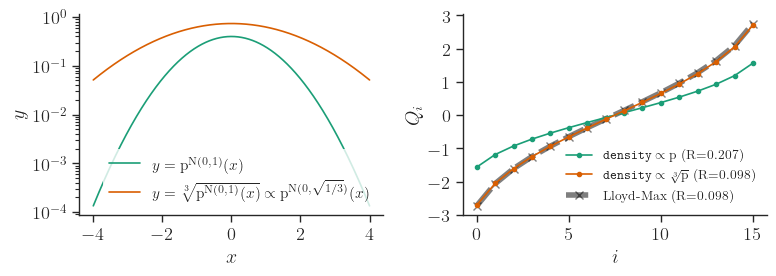

In [88]:
bits = 4
samples = 2**20

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 3))

x = torch.linspace(-4, 4, 1001)
ax0.plot(x, scipy.stats.norm.pdf(x), label=r"$y = \mathrm{p}^{\mathrm{N}(0, 1)}(x)$")
ax0.plot(x, scipy.stats.norm.pdf(x)**(1/3), label=r"$y = \sqrt[3]{\mathrm{p}^{\mathrm{N}(0, 1)}(x)} \propto \mathrm{p}^{\mathrm{N}(0, \sqrt{1/3})}(x)$")
ax0.set_yscale("log")
ax0.set_xlabel("$x$")
ax0.set_ylabel(r"$y$")
ax0.legend(loc="lower right")

dist = A.Normal()
X = dist.sample(samples, seed=1, device=DEVICE)
for fmt in [
        Q.crd_normal(bits, power=1),
        Q.crd_normal(bits),
        Q.lut_lloyd_max(dist.sample(samples, seed=2, device=DEVICE), bits, 1e-4, init=("uniform_rms", 3)),
    ]:
    name = {
        "CRD{1}-N-RS": r"$\texttt{density} \propto \mathrm{p}$",
        "CRD-N-RS": r"$\texttt{density} \propto \sqrt[3]{\mathrm{p}}$",
        "LM": r"Lloyd-Max",
    }[fmt.name]
    rmse = Q.rmse_norm(X, fmt.quantise(X)).item()
    ax1.plot(fmt.values, label=f"{name} (R={rmse:.3f})",
             **(dict(UNDERLAY_ARGS, c="k") if fmt.name == "LM" else dict(marker="o")))
ax1.set_yticks(list(range(-3, 3+1)))
ax1.set_xlabel("$i$")
ax1.set_ylabel("$Q_i$")
ax1.legend(loc="lower right", fontsize=9.5)

fig.tight_layout()
plot_utils.save("normal_crd_example_4bit")

### `crd_curves_4bit`

remote: Updating references: 100% (1/1)           


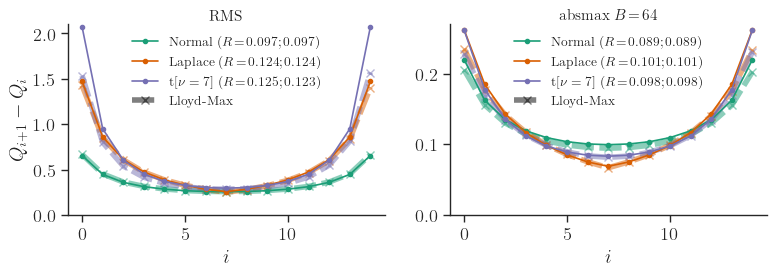

In [90]:
bits = 4
samples = 2**22
t_df = 7
block_size = 64

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 3))

def lut_diff(fmt: Q.LUTFormat) -> Tensor:
    return tensor(fmt.values[1:]) - tensor(fmt.values[:-1])

dists = [
    A.Normal(scale=1),
    A.Laplace(scale=2**-0.5),
    A.StudentT(df=t_df, scale=((t_df - 2) / t_df) ** .5),
]
for dist, color in zip(dists, plot_utils.PALETTE):
    torch.manual_seed(1)
    X = dist.sample(samples, seed=1, device=DEVICE)
    X_LM = dist.sample(samples, seed=2, device=DEVICE)
    assert 0.95 <= A.rms(X).item() <= 1.05

    crd_fmt = dist.rms_quantiser(bits)
    rmse = A.qrmse_norm(crd_fmt, X).item()
    lm_fmt = Q.lut_lloyd_max(X_LM, bits, 1e-4, init=("uniform_rms", 3))
    lm_rmse = A.qrmse_norm(lm_fmt, X).item()

    ax0.plot(lut_diff(crd_fmt), label=f"{distribution_name(dist)} ($R\\!=\\!{rmse:.3f} ; {lm_rmse:.3f}$)", c=color, marker="o")
    ax0.plot(lut_diff(lm_fmt), c=color, **UNDERLAY_ARGS)

    block_crd_fmt = dist.absmax_quantiser(bits, block_size)
    block_rmse = A.qrmse_norm(Q.LinearScalingFormat(block_crd_fmt, Q.BFLOAT16, (block_size,), scaling="absmax"), X).item()
    block_lm_fmt = Q.lut_lloyd_max(A.block_normalise(X_LM, block_size), bits, 1e-4, init="uniform_minmax")
    block_lm_rmse = A.qrmse_norm(Q.LinearScalingFormat(block_lm_fmt, Q.BFLOAT16, (block_size,), scaling="absmax"), X).item()

    ax1.plot(lut_diff(block_crd_fmt), label=f"{distribution_name(dist)} ($R\\!=\\!{block_rmse:.3f} ; {block_lm_rmse:.3f}$)", c=color, marker="o")
    ax1.plot(lut_diff(block_lm_fmt), c=color, **UNDERLAY_ARGS)

for ax in [ax0, ax1]:
    ax.set_xlabel("$i$")
    h, _ = ax.get_legend_handles_labels()
    h.append(matplotlib.lines.Line2D([], [], color="k", **UNDERLAY_ARGS, label="Lloyd-Max"))
    ax.legend(handles=h, loc="upper center", fontsize=9.5)

ax0.set_ylim((0, 2.1))
ax1.set_ylim((0, 0.27))

ax0.set_ylabel("$Q_{i+1} - Q_i$")
ax0.set_title("RMS", y=1, va="center")
ax1.set_title(f"absmax $B\\!=\\!{block_size}$", y=1, va="center")

fig.tight_layout()
plot_utils.save("crd_curves_4bit")

### `dist_absmax`

remote: Updating references: 100% (1/1)           


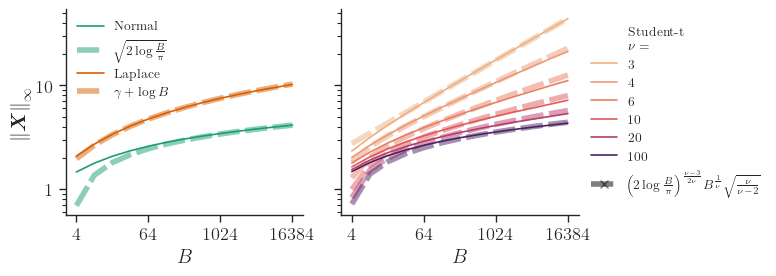

In [91]:
samples = 2**22
B = tensor([2**n for n in range(2, 14+1)])

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 3), sharey=True)

for color, dist in zip(plot_utils.PALETTE, [A.Normal(), A.Laplace()]):
    X = dist.sample(samples, seed=1, device=DEVICE)
    ax0.plot(B, [X.view(-1, Bi).abs().amax(-1).mean().item() for Bi in B], c=color, label=distribution_name(dist))
    if isinstance(dist, A.Normal):
        model = B.div(torch.pi).log().mul(2).sqrt()
        model_label = r"$\sqrt{2 \log \frac{B}{\pi}}$"
    if isinstance(dist, A.Laplace):
        model = B.log().add(0.57721566)
        model_label = r"$\gamma + \log B$"
    ax0.plot(B, model, **{**UNDERLAY_ARGS, "marker": None}, c=color, label=model_label)
ax0.legend(loc="upper left", fontsize=9.5)

t_dfs = tensor([3, 4, 6, 10, 20, 100])
for df, color in zip(t_dfs, plot_utils.SEQ_PALETTE(matplotlib.colors.LogNorm()(t_dfs))):
    X = A.StudentT(df.item()).sample(samples, seed=1, device=DEVICE)
    ax1.plot(B, [X.view(-1, Bi).abs().amax(-1).mean().item() for Bi in B], c=color, label=f"{df:.0f}")
    model = B.double().div(torch.pi).log().mul(2).pow((df-3)/2).mul(B).pow(1/df).mul((df/(df-2)).sqrt())
    ax1.plot(B, model, **{**UNDERLAY_ARGS, "marker": None}, c=color)
model_label = r"$\left(2 \log \frac{B}{\pi}\right)^{\frac{\nu-3}{2 \nu}}\! B^{\frac{1}{\nu}} \sqrt{\frac{\nu}{\nu - 2}}$"
h, _ = ax1.get_legend_handles_labels()
h.insert(0, matplotlib.lines.Line2D([], [], alpha=0, label="Student-t\n$\\nu=$"))
h.append(matplotlib.lines.Line2D([], [], color="k", **UNDERLAY_ARGS, label=model_label))
ax1.legend(handles=h, bbox_to_anchor=(1, 0.5), loc="center left", fontsize=9.5)

for ax in [ax0, ax1]:
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks([4, 64, 1024, 16384])
    ax.xaxis.set_major_formatter("{x:.0f}")
    ax.yaxis.set_major_formatter("{x:.0f}")
    ax.set_xlabel("$B$")
ax0.set_ylabel(r"$\norm{\bm{X}}{\infty}$")

fig.tight_layout()
plot_utils.save("dist_absmax")

## Block vs independent formats on iid data

### Preamble

In [ ]:
samples = 2**20
bs = torch.linspace(3, 6, 13).tolist()
Bs = [2**logB for logB in range(3, 12+1)]
distributions = [A.Normal(), A.Laplace(), A.StudentT(df=5)]

def sweep() -> Iterable[dict[str, Any]]:
    for dist in distributions:
        X = dist.sample(samples, seed=1, device=DEVICE)
        for b in tqdm.tqdm(bs, desc=type(dist).__name__):
            fmts = []

            for edist in distributions:
                fmts.append((Q.LinearScalingFormat(edist.rms_quantiser(b), Q.BFLOAT16, (None,), scaling="rms"),
                             dict(scaling="rms", edist_name=distribution_name(edist))))
                for B in Bs:
                    fmts.append((Q.LinearScalingFormat(edist.absmax_quantiser(b - 16 / B, B, scaling="absmax", mode="symmetric"), Q.BFLOAT16, (B,), scaling="absmax"),
                                    dict(scaling="absmax", block_size=B, edist_name=distribution_name(edist))))

            # Lloyd-Max
            # fmts.append((Q.LinearScalingFormat(Q.lut_lloyd_max(A.rms_normalise(X), b, 1e-4, init=("uniform_rms", 3)), Q.BFLOAT16, (None,), scaling="rms"),
            #              dict(scaling="rms")))
            # for edist in distributions:
            #     fmts.append((Q.LinearScalingFormat(Q.lut_lloyd_max(A.block_normalise(X, B), b - 16 / B, 1e-4, init="uniform_minmax"), Q.BFLOAT16, (B,), scaling="absmax"),
            #                     dict(scaling="absmax", block_size=B)))

            for fmt, detail in fmts:
                yield dict(
                    dist=distribution_name(dist),
                    dist_type=type(dist).__name__,
                    fmt=str(fmt),
                    efmt=fmt.element_format.name,
                    **detail,
                    bits=fmt.count_bits(X.shape) / X.nelement(),
                    qrmse_norm=A.qrmse_norm(fmt, X).item(),
                )

df = pd.DataFrame.from_records(list(sweep()))
display(df)

StudentT: 100%|██████████| 13/13 [00:00<00:00, 53.37it/s]


,dist,dist_type,fmt,efmt,scaling,edist_name,bits,qrmse_norm,block_size
0,Normal,Normal,LUT3[CRD-N-RS]{*:BFLOAT16:rms},CRD-N-RS,rms,Normal,3.000015,0.186338,NaN
1,Normal,Normal,LUT1[CRD-N-AS]{8:BFLOAT16:absmax},CRD-N-AS,absmax,Normal,3.000000,1.208012,8.0
2,Normal,Normal,LUT2[CRD-N-AS]{16:BFLOAT16:absmax},CRD-N-AS,absmax,Normal,3.000000,0.380959,16.0
3,Normal,Normal,LUT3[CRD-N-AS]{32:BFLOAT16:absmax},CRD-N-AS,absmax,Normal,2.821929,0.314571,32.0
4,Normal,Normal,LUT3[CRD-N-AS]{64:BFLOAT16:absmax},CRD-N-AS,absmax,Normal,2.834963,0.269938,64.0
...,...,...,...,...,...,...,...,...,...
1282,t[$\nu=5$],StudentT,LUT6[CRD-T[5]-AS]{256:BFLOAT16:absmax},CRD-T[5]-AS,absmax,t[$\nu=5$],5.993237,0.029764,256.0
1283,t[$\nu=5$],StudentT,LUT6[CRD-T[5]-AS]{512:BFLOAT16:absmax},CRD-T[5]-AS,absmax,t[$\nu=5$],5.985447,0.031181,512.0
1284,t[$\nu=5$],StudentT,LUT6[CRD-T[5]-AS]{1024:BFLOAT16:absmax},CRD-T[5]-AS,absmax,t[$\nu=5$],5.992906,0.032202,1024.0
1285,t[$\nu=5$],StudentT,LUT6[CRD-T[5]-AS]{2048:BFLOAT16:absmax},CRD-T[5]-AS,absmax,t[$\nu=5$],5.985093,0.033670,2048.0


### `analysis_error_vs_bits`

remote: Updating references: 100% (1/1)           


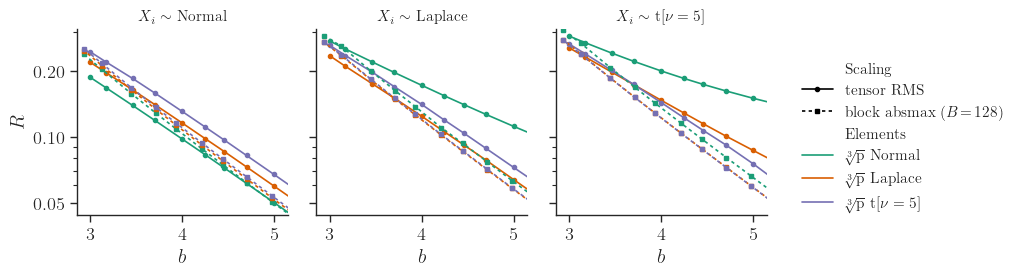

In [86]:
plt_args = dict(
    rms=dict(marker="o"),
    absmax=dict(ls=(0, (2, 2)), marker="s"),
)
edist_to_color = dict(zip(df["edist_name"].unique(), plot_utils.PALETTE))
block_size = 128

g = plot_utils.grid(df[(df["efmt"] != "LM")], col="dist", sharey=True)
for (dist,), d, ax in g:
    for edist_name, dd in d[(d["scaling"] == "rms")].groupby("edist_name", sort=False):
        dd.plot(y="qrmse_norm", ylabel="qrmse_norm", x="bits", color=edist_to_color[edist_name], **plt_args["rms"], label="_nolabel", ax=ax)

    dash_offset = 0
    for edist_name, dd in d[(d["scaling"] == "absmax") & (d["block_size"] == block_size)].groupby("edist_name", sort=False):
        dd.plot(y="qrmse_norm", ylabel="qrmse_norm", x="bits", color=edist_to_color[edist_name],
                **{**plt_args["absmax"], "ls": (dash_offset, plt_args["absmax"]["ls"][1])}, label="_nolabel", ax=ax)
        dash_offset += 1.25

    ax.set_yscale("log")
    ax.set_ylim((0.044, 0.31))
    ax.yaxis.set_major_formatter("{x:.2f}")
    ax.yaxis.set_ticks([0.05, 0.1, 0.2])
    ax.tick_params(axis="y", which="minor", labelleft=False)
    ax.set_xlim((3-0.15, 5+0.15))
    ax.set_xticks(list(range(3, 5+1)))

    ax.set_title(f"$X_i \\sim$ {dist}")

h = []
h.append(matplotlib.patches.Patch(facecolor="none", label="Scaling"))
h.append(matplotlib.lines.Line2D([], [], color="k", **plt_args["rms"], label=f"tensor RMS"))
h.append(matplotlib.lines.Line2D([], [], color="k", **plt_args["absmax"], label=f"block absmax ($B\\!=\\!{block_size}$)"))
h.append(matplotlib.patches.Patch(facecolor="none", label="Elements"))
for edist_name, color in edist_to_color.items():
    h.append(matplotlib.lines.Line2D([], [], color=color, label=f"{plot_utils.CRP_LABEL} {edist_name}"))
g.figure.legend(handles=h, loc="center left", bbox_to_anchor=(1, 0.5))

plot_utils.tidy(g.figure)
plot_utils.save("analysis_error_vs_bits")

### `analysis_block_size_4bit`

remote: Updating references: 100% (1/1)           


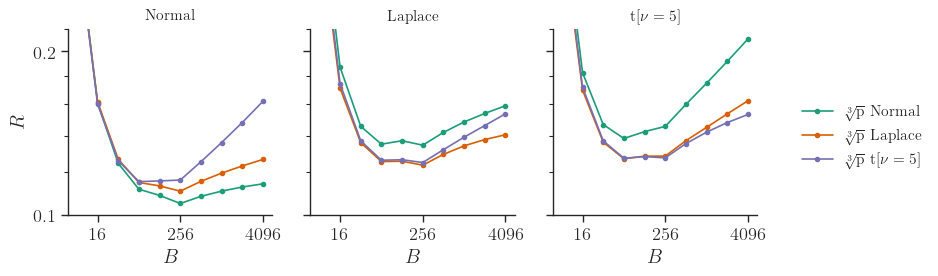

In [79]:
b = 4

g = plot_utils.grid(df[(df["scaling"] != "rms") & (b - 0.25 < df["bits"]) & (df["bits"] <= b)], col="dist", sharey=True)
for (dist,), d, ax in g:
    for efmt, dd in d.groupby("efmt", sort=False):
        dd.sort_values("block_size").plot(y="qrmse_norm", ylabel="qrmse_norm", x="block_size", label=efmt, marker="o", ax=ax)

    ax.set_yscale("log")
    ax.set_ylim((0.1, 0.22))
    ax.set_yticks([0.1, 0.2])
    ax.yaxis.set_major_formatter("{x:.1f}")
    ax.tick_params(axis="y", which="minor", labelleft=False)
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter("{x:.0f}")
    ax.set_xticks([16, 256, 4096])

    ax.set_title(dist)

plot_utils.share_legend(g.figure)
plot_utils.tidy(g.figure)
plot_utils.save("analysis_block_size_4bit")